In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
import datetime
import random
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

## Reading the Dataset


In [2]:
from google.colab import files
uploaded = files.upload()

Saving PBL_Student_Mental_Health.csv to PBL_Student_Mental_Health.csv


In [3]:
df = pd.read_csv('PBL_Student_Mental_Health.csv')
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [4]:
df.dtypes

,0
Timestamp,object
Choose your gender,object
Age,float64
What is your course?,object
Your current year of Study,object
What is your CGPA?,object
Marital status,object
Do you have Depression?,object
Do you have Anxiety?,object
Do you have Panic attack?,object


In [5]:
df.shape

(101, 11)

In [6]:
df.nunique()

,0
Timestamp,92
Choose your gender,2
Age,7
What is your course?,49
Your current year of Study,7
What is your CGPA?,6
Marital status,2
Do you have Depression?,2
Do you have Anxiety?,2
Do you have Panic attack?,2


In [7]:
df.isnull().sum()

,0
Timestamp,0
Choose your gender,0
Age,1
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [8]:
df = df.dropna(how = 'any', axis = 0)
df.isnull().sum()

,0
Timestamp,0
Choose your gender,0
Age,0
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


## Data Visualization

Text(0.5, 1.0, 'Age distribution')

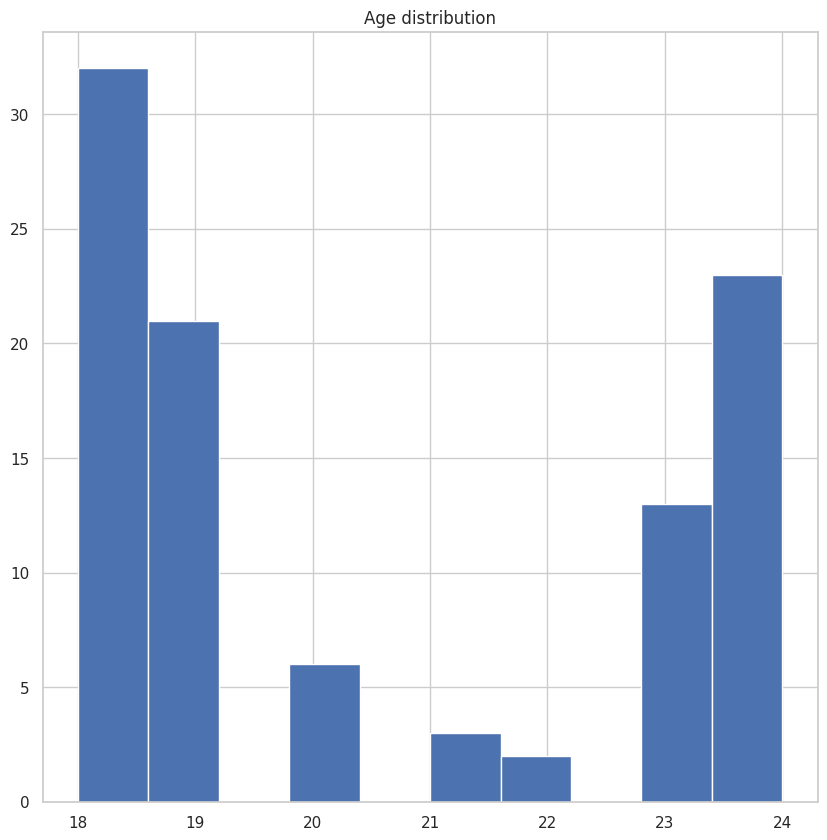

In [9]:
plt.figure(figsize = (10,10))
plt.hist(df['Age'], color = 'b')
plt.title("Age distribution")

In [10]:
df.rename(columns = {'Choose your gender': 'gender'}, inplace = True)

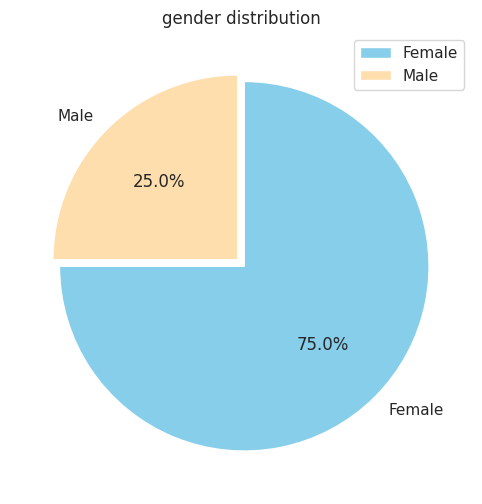

In [11]:
plt.figure(figsize = (12,6))
plt.title("gender distribution")
g = plt.pie(df.gender.value_counts(), explode = (0.025,0.025), labels = df.gender.value_counts().index, colors = ['skyblue','navajowhite'], autopct = '%1.1f%%', startangle = 180)
plt.legend()
plt.show()

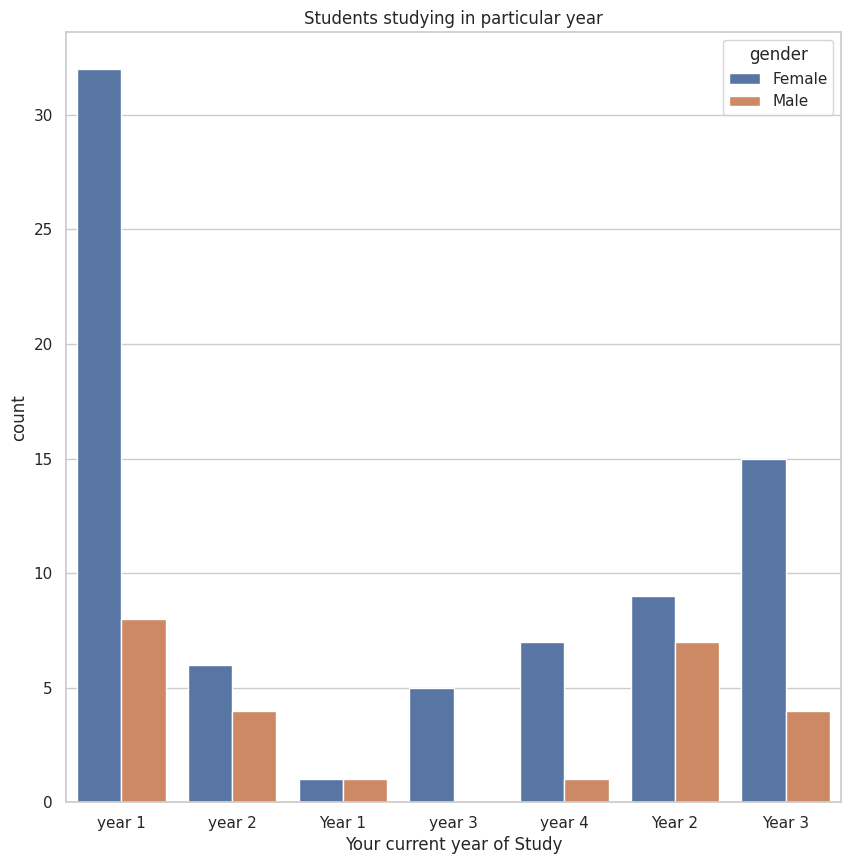

In [12]:
plt.figure(figsize = (10,10))
sns.countplot(data = df, x = 'Your current year of Study', hue = 'gender')
plt.title("Students studying in particular year")
plt.show()

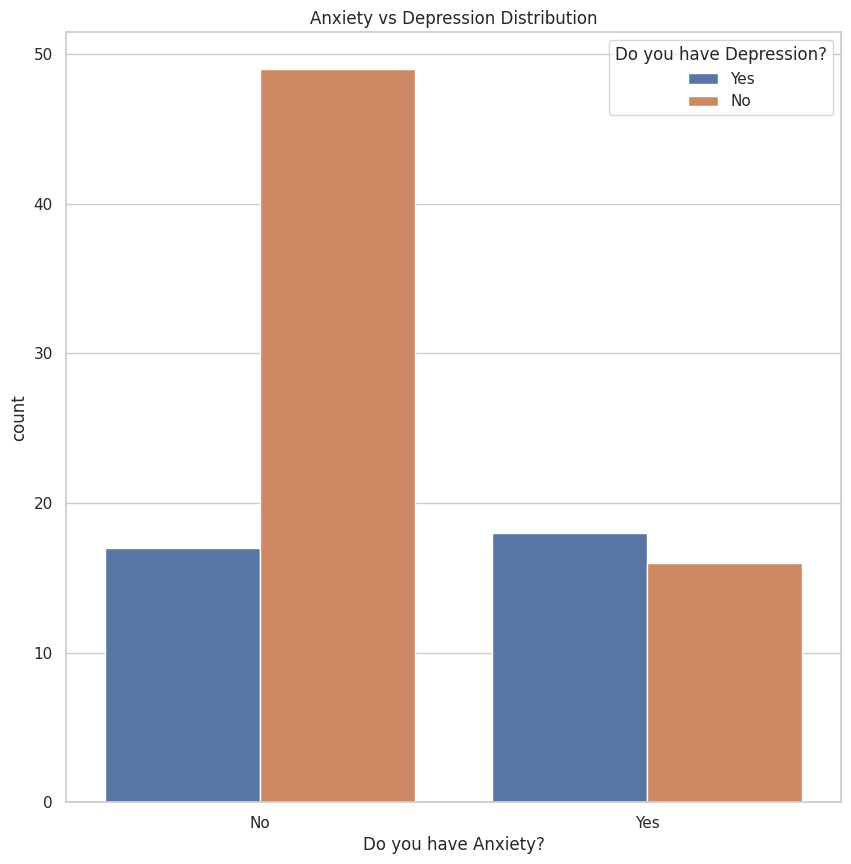

In [13]:
plt.figure(figsize = (10,10))

sns.countplot(data = df, x = 'Do you have Anxiety?', hue = 'Do you have Depression?')

plt.title("Anxiety vs Depression Distribution")
plt.show()

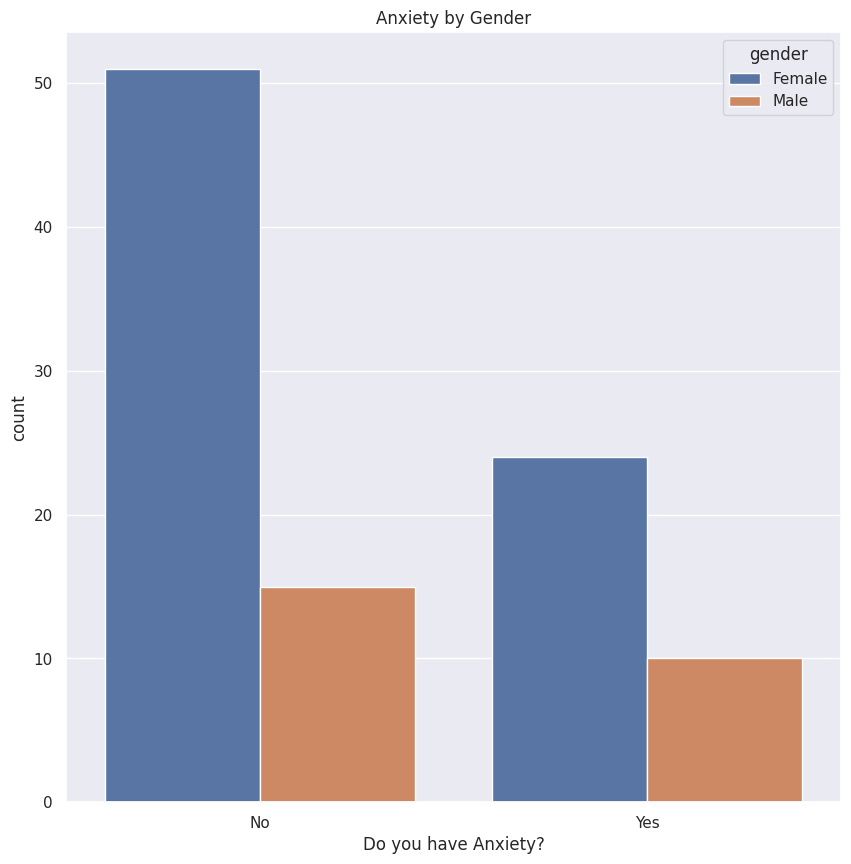

In [14]:
plt.figure(figsize = (10,10))
sns.set_theme(style = "darkgrid")
ax = sns.countplot(x = "Do you have Anxiety?", hue = "gender", data = df)
plt.title("Anxiety by Gender")
plt.show()

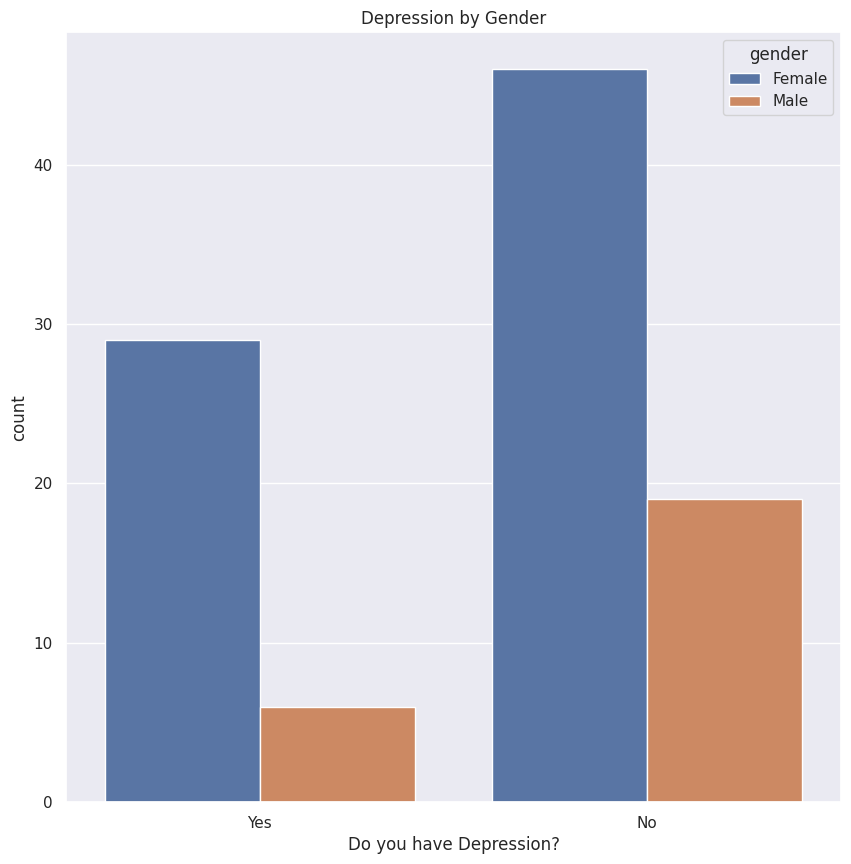

In [15]:
plt.figure(figsize = (10,10))
sns.set_theme(style = "darkgrid")
ax = sns.countplot(x = "Do you have Depression?", hue = "gender", data = df)
plt.title("Depression by Gender")
plt.show()

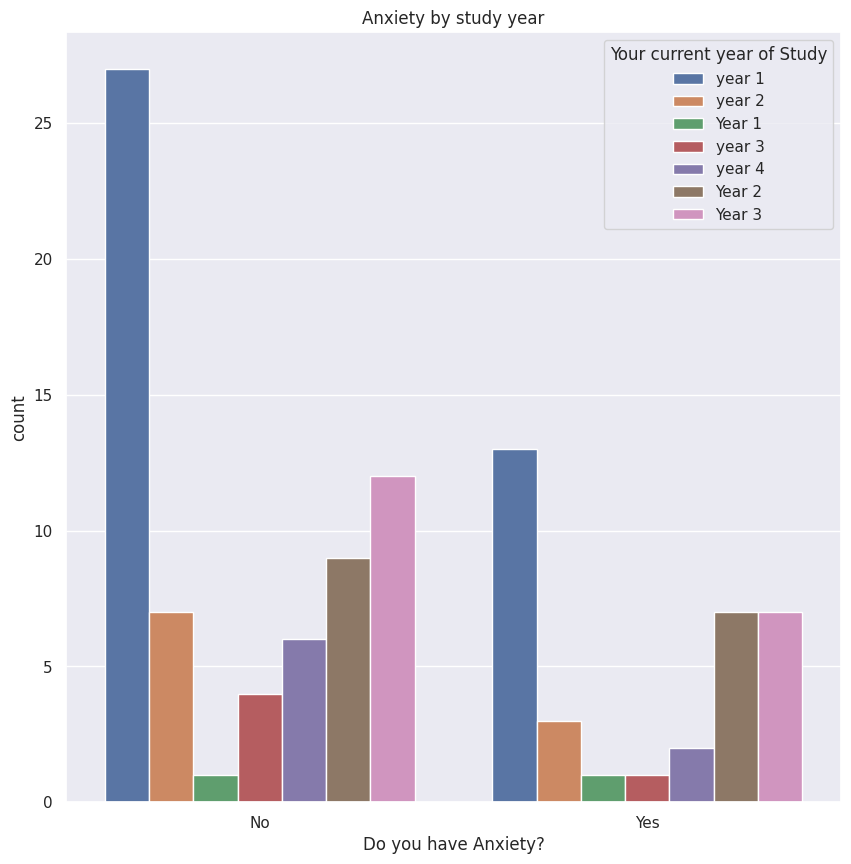

In [16]:
plt.figure(figsize = (10,10))
sns.set_theme(style = "darkgrid")
ax = sns.countplot(x = "Do you have Anxiety?", hue = "Your current year of Study", data = df)
plt.title("Anxiety by study year")
plt.show()

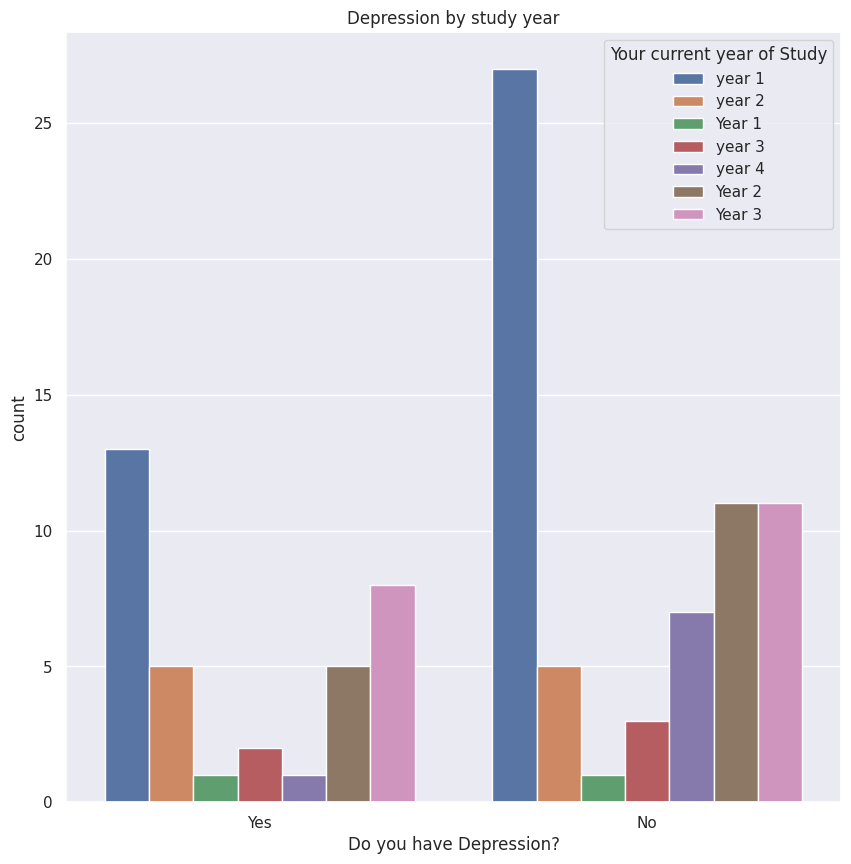

In [17]:
plt.figure(figsize = (10,10))
sns.set_theme(style = "darkgrid")
ax = sns.countplot(x = "Do you have Depression?", hue = "Your current year of Study", data = df)
plt.title("Depression by study year")
plt.show()

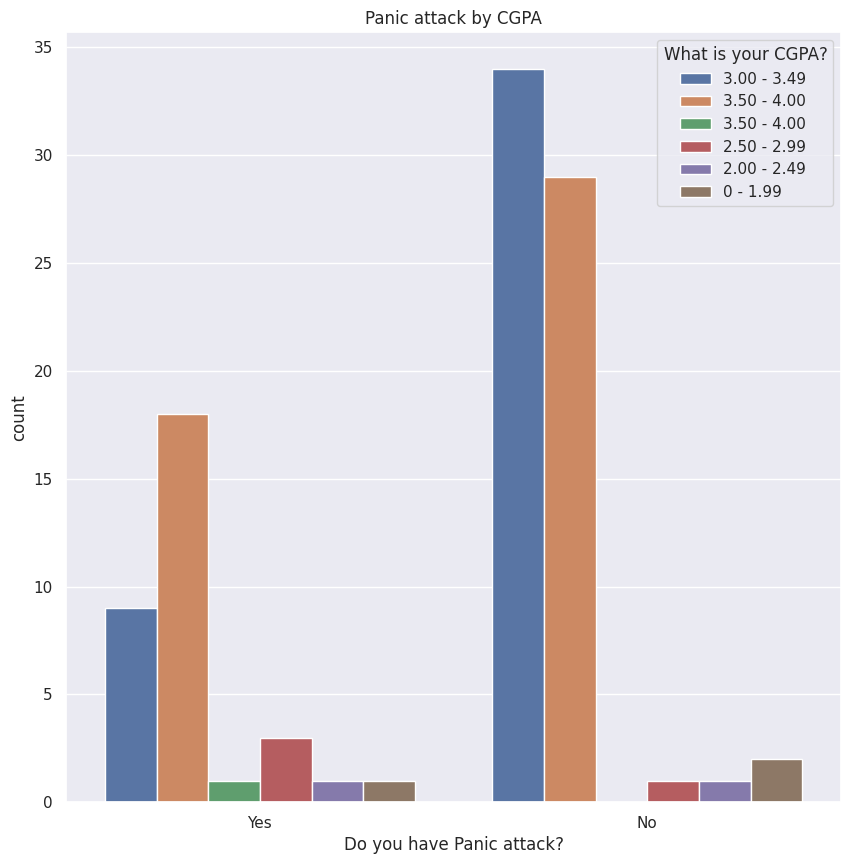

In [18]:
plt.figure(figsize = (10,10))
sns.set_theme(style = "darkgrid")
ax = sns.countplot(x = "Do you have Panic attack?", hue = "What is your CGPA?", data = df)
plt.title("Panic attack by CGPA")
plt.show()

## Data Preprocessing

In this section, we prepare the dataset for machine learning models by:
- Cleaning column names
- Encoding categorical variables
- Dropping irrelevant features

In [20]:
df.columns = df.columns.str.strip()

df = df.drop(columns=['Timestamp'])

encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

## Train-Test Split

We split the dataset into training and testing sets to evaluate model performance.

In [21]:
X = df.drop('Do you have Depression?', axis=1)
y = df['Do you have Depression?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

We train multiple machine learning models to compare their performance:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [23]:
results = {}

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test))


dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test))


rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test))


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(probability = True)
svm.fit(X_train_scaled, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test_scaled))


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
results['XGBoost'] = accuracy_score(y_test, xgb.predict(X_test))


for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.8000
Decision Tree: 0.8000
Random Forest: 0.8500
SVM: 0.9000
XGBoost: 0.6500


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:48:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model Evaluation

We compare model performance based on accuracy.

In [24]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
3                  SVM      0.90
2        Random Forest      0.85
0  Logistic Regression      0.80
1        Decision Tree      0.80
4              XGBoost      0.65


## 📊 Observations

- **SVM** achieved the highest accuracy (**0.90**), indicating strong performance on this dataset (likely due to proper feature scaling).
- **Logistic Regression** and **Random Forest** performed equally well (**0.80**), making them reliable baseline and ensemble options.
- **Decision Tree** and **XGBoost** showed lower accuracy (**0.65**), suggesting possible overfitting (Decision Tree) or insufficient tuning (XGBoost).
- Despite general expectations, **Random Forest and XGBoost did not outperform simpler models**, likely due to dataset size or lack of hyperparameter tuning.
- Model performance is **dataset-dependent**, and proper preprocessing and tuning can significantly change rankings.

In [28]:
import pandas as pd
from sklearn.metrics import classification_report

y_pred = svm.predict(X_test_scaled)

report_dict = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

print(report_df)

              precision  recall  f1-score  support
0              0.882353     1.0  0.937500     15.0
1              1.000000     0.6  0.750000      5.0
accuracy       0.900000     0.9  0.900000      0.9
macro avg      0.941176     0.8  0.843750     20.0
weighted avg   0.911765     0.9  0.890625     20.0


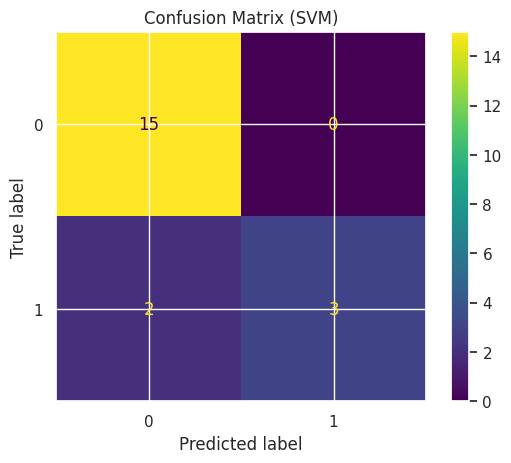

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (SVM)")
plt.show()

## 🔍 Explainable AI (XAI) Method

To interpret the predictions of our model, we used **Permutation Importance**, a model-agnostic Explainable AI (XAI) technique.

Permutation Importance evaluates the contribution of each feature by measuring the decrease in model performance when the values of a feature are randomly shuffled. A larger drop in performance indicates that the feature is more important for the model’s predictions.

This method is particularly suitable for our approach since we implemented a **Support Vector Machine (SVM) with an RBF kernel**, which is a non-linear model and does not provide intrinsic feature importance scores.

By applying permutation importance to the trained SVM model, we are able to identify and rank the most influential features contributing to the prediction of student depression, thereby improving the interpretability of the model.

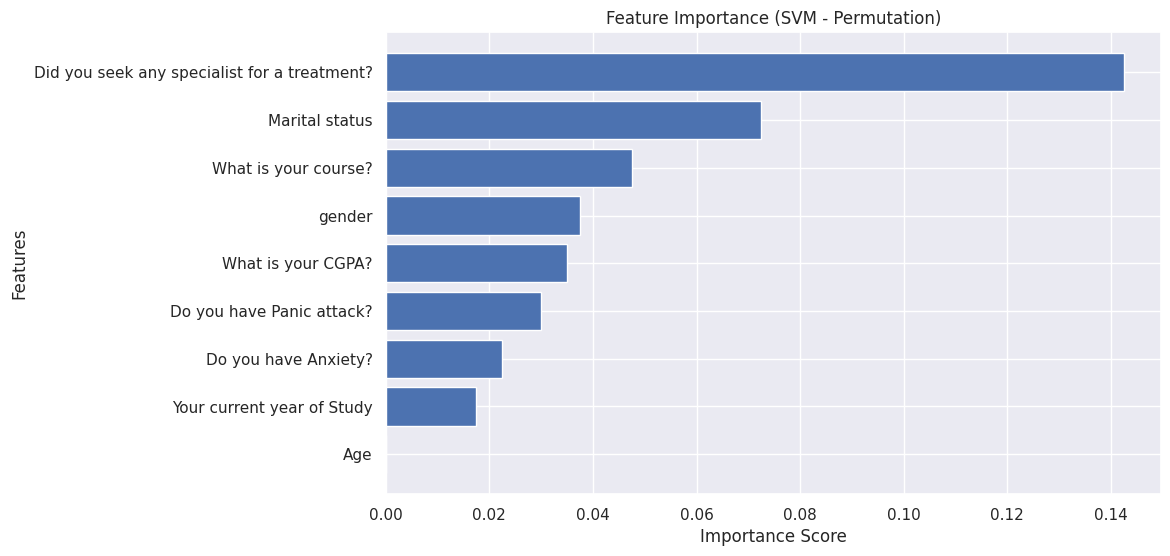

In [ ]:
result = permutation_importance(svm, X_test_scaled, y_test, n_repeats = 20, random_state = 42, n_jobs = -1)

perm_imp = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean}).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (10,6))
plt.barh(perm_imp['Feature'], perm_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (SVM - Permutation)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

/tmp/ipykernel_17848/2699779409.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert = False, labels = X.columns[sorted_idx])


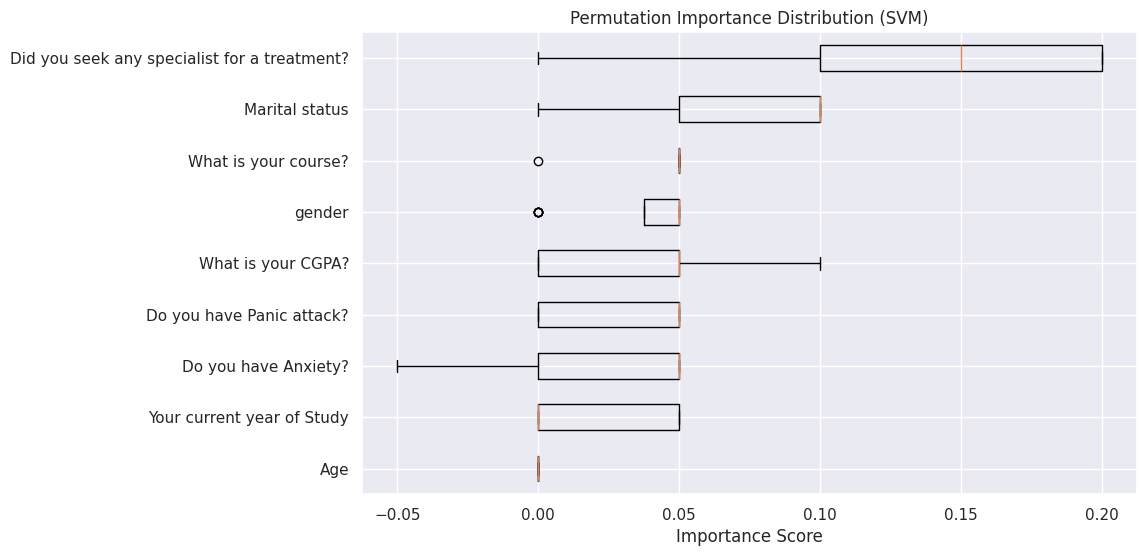

                                        Feature  Importance
8  Did you seek any specialist for a treatment?      0.1425
5                                Marital status      0.0725
2                          What is your course?      0.0475
0                                        gender      0.0375
4                            What is your CGPA?      0.0350
7                     Do you have Panic attack?      0.0300
6                          Do you have Anxiety?      0.0225
3                    Your current year of Study      0.0175
1                                           Age      0.0000


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(svm, X_test_scaled, y_test, n_repeats = 20, random_state = 42, n_jobs = -1)

sorted_idx = result.importances_mean.argsort()

plt.figure(figsize = (10,6))
plt.boxplot(result.importances[sorted_idx].T, vert = False, labels = X.columns[sorted_idx])
plt.title("Permutation Importance Distribution (SVM)")
plt.xlabel("Importance Score")
plt.show()

print(perm_imp)

  ### 📊 Observations

- The most influential feature in predicting depression is **"Did you seek any specialist for a treatment?"**, indicating that prior mental health consultation or treatment history has the strongest impact on the model’s predictions.

- **Marital status** is the second most important feature, suggesting that personal life circumstances significantly influence mental well-being.

- **"What is your course?"** ranks third in importance. This highlights that a student’s academic background plays a crucial role in mental health, as different courses involve varying levels of workload, competition, and career pressure.

- **Gender** and **CGPA** show moderate importance, indicating that both demographic characteristics and academic performance contribute to depression prediction to some extent.

- **Panic attacks** and **Anxiety** have noticeable but relatively lower importance. While they are clinically related to mental health, their predictive contribution in this dataset is less dominant compared to other factors.

- **Year of study** has a smaller influence, suggesting that progression through academic years alone does not strongly determine depression levels.

- **Age** has the least importance, indicating minimal variation in depression prediction across different age groups within the dataset.

- Overall, the results suggest that **personal factors (such as treatment history and marital status)** have a stronger influence, while **academic factors (such as course and performance)** still play a meaningful and student-specific role in predicting depression.

In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)